# US Firm Characteristics: Allocator Sweep

**Chapter 17 - Portfolio Construction**

The backtest notebook weighted every selected name equally. That is a choice, not
an absence of one: equal weighting throws away the model's own ranking inside the
selected set, on the argument that the ranking is too noisy to size with. This
notebook tests that argument by sizing positions three ways and comparing what
each earned.

An **allocator** turns a set of selected names into weights. Two are declared for
this case study. **Score weighting** sizes each position by the model's own
predicted score, so a name the model is more confident about gets more capital.
**Conformal weighting** sizes by an interval rather than a point estimate: it
calibrates, on data the model did not fit, how wide each prediction's error
distribution is, and gives less capital to names whose predictions have been less
reliable. The two disagree exactly where a large score comes with a wide interval.

The sweep crosses those allocators with the concentration levels the backtest
notebook already swept, so the comparison holds concentration fixed within each
cell rather than confounding it with the sizing rule.

Sections 1-2 write allocation backtests to the registry. Section 3 is read-only:
it queries the registry through `BacktestExplorer` and can be re-run without
re-running the sweep.

**Book Reference:** Chapter 17, Sections 17.2-17.8

**Prerequisites:** the Chapter 16 backtest notebook, whose registered baselines
decide which predictions advance to here.

In [1]:
"""US Firm Characteristics: Portfolio: Allocator Sweep."""

import sqlite3
import time
import warnings
from collections import Counter

import polars as pl

from utils.style import COLORS, add_message_title

warnings.filterwarnings("ignore")

from case_studies.utils.backtest_loaders import get_backtest_config, load_backtest_prices_for
from case_studies.utils.backtest_presets import build_backtest_spec
from case_studies.utils.backtest_runner import run_backtest
from case_studies.utils.registry import read_predictions, resolve_best_predictions
from case_studies.utils.sweep_config import (
    get_allocators,
    get_checkpoints_per_config,
    get_top_k_values_for,
    get_top_n_predictions,
)
from utils.paths import get_case_study_dir

In [2]:
CASE_STUDY_ID = "us_firm_characteristics"
LABEL = ""
MAX_SYMBOLS = 0
TOP_N_PREDICTIONS = None

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
bt_config = get_backtest_config(CASE_STUDY_ID)
if TOP_N_PREDICTIONS is None:
    TOP_N_PREDICTIONS = get_top_n_predictions(CASE_STUDY_ID, "allocation")
CHECKPOINTS_PER_CONFIG = get_checkpoints_per_config(CASE_STUDY_ID)
if not LABEL:
    LABEL = bt_config.primary_label

print(f"Case study: {CASE_STUDY_ID}, label: {LABEL}")

Case study: us_firm_characteristics, label: fwd_ret_1m


## 1. Which predictions advance

Allocation is swept over the predictions that ranked highest at the equal-weight
baseline rather than over all of them, because the sweep is multiplicative:
every prediction carried forward is multiplied by the concentration grid and
again by the allocator menu. That selection is itself a source of the overfitting
the strategy analysis notebook has to correct for, and it is recorded here as a
step rather than treated as neutral.

In [4]:
top_preds = resolve_best_predictions(
    CASE_STUDY_ID,
    LABEL,
    split="validation",
    stage="signal",
    top_n=TOP_N_PREDICTIONS,
    checkpoints_per_config=CHECKPOINTS_PER_CONFIG,
)
print(f"Top {len(top_preds)} prediction sources by equal-weight baseline Sharpe:")
print(top_preds.select(["source", "sharpe"]))

Top 10 prediction sources by equal-weight baseline Sharpe:
shape: (10, 2)
┌─────────────────────┬──────────┐
│ source              ┆ sharpe   │
│ ---                 ┆ ---      │
│ str                 ┆ f64      │
╞═════════════════════╪══════════╡
│ gbm/leaves_63_mse   ┆ 2.863285 │
│ gbm/leaves_7_mse    ┆ 2.821778 │
│ gbm/leaves_15_mse   ┆ 2.596387 │
│ gbm/default_mse     ┆ 2.564738 │
│ gbm/leaves_31_mse   ┆ 2.520234 │
│ gbm/leaves_63_mae   ┆ 2.310584 │
│ gbm/leaves_7_huber  ┆ 2.229408 │
│ gbm/leaves_63_huber ┆ 2.114088 │
│ gbm/leaves_15_mae   ┆ 2.085353 │
│ gbm/default_huber   ┆ 2.074565 │
└─────────────────────┴──────────┘


In [5]:
prices = load_backtest_prices_for(CASE_STUDY_ID, LABEL, split="validation", max_symbols=MAX_SYMBOLS)
n_assets = prices["symbol"].n_unique()
print(f"Prices: {len(prices):,} rows, {n_assets} assets")

Prices: 252,008 rows, 3708 assets


## 2. Allocation Sweep

Each cell of the grid is one prediction, one concentration and one allocator, run
through the same `run_backtest()` the baseline used. The allocation config enters
the strategy spec, so the spec hash separates these runs from the equal-weight
baselines rather than overwriting them, and both stages stay readable side by side.

The concentration grid is printed below with the universe it was resolved against.
A small value concentrates capital in the names the model ranked highest; a large
one spreads it across names the model ranked lower, so the grid trades conviction
against diversification.

The declared menu is score weighting and conformal weighting. Four allocators the
other case studies sweep are absent, for two different reasons; `setup.yaml` states
both, above its `execution:` block.

Hierarchical risk parity and mean-variance optimisation estimate a correlation or
covariance matrix over the held names from a rolling window. The window here is
twelve monthly bars, so the matrix has rank at most eleven, while a long-short book
holds twice the concentration level - ten names at the narrowest grid point below and
a hundred at the widest. Both are therefore identified at the narrowest point and
unidentified at the other three. Shrinkage does not change that: the case-study
lookback is injected as the MVO window, so it is twelve observations there too.

Inverse-volatility and risk-parity weighting need no matrix. Each weights by a
per-asset rolling standard deviation, which twelve observations do estimate, if
noisily. They are absent by decision rather than by identification: this case study
keeps the allocation stage to the equal-weight baseline and the two alternatives that
need no lookback at all.

In [6]:
TOP_K_VALUES = get_top_k_values_for(CASE_STUDY_ID, LABEL, n_assets)
print(f"TOP_K grid: {TOP_K_VALUES} (universe: {n_assets} assets)")

ALLOC_CONFIGS = get_allocators(CASE_STUDY_ID)
ADVANCED_HASHES = top_preds["prediction_hash"].to_list()

n_total = len(top_preds) * len(TOP_K_VALUES) * len(ALLOC_CONFIGS)
print(
    f"Total backtests: {len(top_preds)} preds x {len(TOP_K_VALUES)} top_k x "
    f"{len(ALLOC_CONFIGS)} allocs = {n_total}"
)

TOP_K grid: [5, 10, 20, 50] (universe: 3708 assets)
Total backtests: 10 preds x 4 top_k x 2 allocs = 80


In [7]:
n_done = 0
n_failed = 0
failures: Counter[str] = Counter()
sweep_start = time.monotonic()

for top_k in TOP_K_VALUES:
    print(f"\n--- TOP_K = {top_k} ---")
    for pred_row in top_preds.iter_rows(named=True):
        pred_hash = pred_row["prediction_hash"]
        source = pred_row["source"]

        predictions = read_predictions(CASE_STUDY_ID, pred_hash)

        for alloc in ALLOC_CONFIGS:
            alloc_name = alloc["method"]
            n_done += 1

            spec = build_backtest_spec(
                CASE_STUDY_ID,
                bt_config,
                prices=prices,
                prediction_hash=pred_hash,
                initial_cash=bt_config.initial_cash,
                chapter="ch17",
                signal={
                    "method": "equal_weight_top_k",
                    "top_k": top_k,
                    "long_short": bt_config.long_short,
                },
                allocation={**alloc, "top_k": top_k, "long_short": bt_config.long_short},
            )

            try:
                result = run_backtest(
                    CASE_STUDY_ID,
                    pred_hash,
                    spec,
                    prices=prices,
                    predictions=predictions,
                    label=LABEL,
                    register=True,
                    initial_cash=bt_config.initial_cash,
                    calendar=bt_config.calendar,
                )

                print(
                    f"  [{n_done}/{n_total}] k={top_k} {source} x {alloc_name}: "
                    f"Sharpe={result.metrics.get('sharpe', 0):.3f}"
                )
            except Exception as error:
                n_failed += 1
                failures[f"{type(error).__name__}: {error}"] += 1
                print(
                    f"  [{n_done}/{n_total}] k={top_k} {source} x {alloc_name}: "
                    f"FAILED - {type(error).__name__}: {error}"
                )

print(
    f"\nSweep completed in {(time.monotonic() - sweep_start) / 60:.1f} minutes ({n_failed} failed)"
)
for reason, count in failures.most_common():
    print(f"  {count:>4} x {reason[:150]}")


--- TOP_K = 5 ---
  SKIP backtest (complete (hash=f82ef7fcdf46)) — reusing cached result
  [1/80] k=5 gbm/leaves_63_mse x score_weighted: Sharpe=0.962


  SKIP backtest (complete (hash=9663f0367c22)) — reusing cached result
  [2/80] k=5 gbm/leaves_63_mse x conformal_weighted: Sharpe=1.080


  SKIP backtest (complete (hash=c5c3296185ce)) — reusing cached result
  [3/80] k=5 gbm/leaves_7_mse x score_weighted: Sharpe=1.371
  SKIP backtest (complete (hash=c913df6450f2)) — reusing cached result


  [4/80] k=5 gbm/leaves_7_mse x conformal_weighted: Sharpe=1.494
  SKIP backtest (complete (hash=6c19c941d333)) — reusing cached result


  [5/80] k=5 gbm/leaves_15_mse x score_weighted: Sharpe=1.134
  SKIP backtest (complete (hash=bf8f3a08dc9e)) — reusing cached result
  [6/80] k=5 gbm/leaves_15_mse x conformal_weighted: Sharpe=1.314


...

  SKIP backtest (complete (hash=565ed3a16c37)) — reusing cached result
  [70/80] k=50 gbm/leaves_31_mse x conformal_weighted: Sharpe=2.577
  SKIP backtest (complete (hash=0727c76e6ca5)) — reusing cached result
  [71/80] k=50 gbm/leaves_63_mae x score_weighted: Sharpe=2.295


  SKIP backtest (complete (hash=1c865bc37a2d)) — reusing cached result
  [72/80] k=50 gbm/leaves_63_mae x conformal_weighted: Sharpe=2.083
  SKIP backtest (complete (hash=f8d0f1e42b59)) — reusing cached result
  [73/80] k=50 gbm/leaves_7_huber x score_weighted: Sharpe=1.429
  SKIP backtest (complete (hash=9318b552cfb9)) — reusing cached result
  [74/80] k=50 gbm/leaves_7_huber x conformal_weighted: Sharpe=1.094


  SKIP backtest (complete (hash=9a74f18cb071)) — reusing cached result
  [75/80] k=50 gbm/leaves_63_huber x score_weighted: Sharpe=2.099
  SKIP backtest (complete (hash=aea61bc674f4)) — reusing cached result
  [76/80] k=50 gbm/leaves_63_huber x conformal_weighted: Sharpe=1.953


  SKIP backtest (complete (hash=4dd3e01e9f34)) — reusing cached result
  [77/80] k=50 gbm/leaves_15_mae x score_weighted: Sharpe=1.898
  SKIP backtest (complete (hash=2b84335b03ad)) — reusing cached result
  [78/80] k=50 gbm/leaves_15_mae x conformal_weighted: Sharpe=1.524
  SKIP backtest (complete (hash=723f14c26235)) — reusing cached result
  [79/80] k=50 gbm/default_huber x score_weighted: Sharpe=2.128


  SKIP backtest (complete (hash=ba4f4acad6d4)) — reusing cached result
  [80/80] k=50 gbm/default_huber x conformal_weighted: Sharpe=1.911

Sweep completed in 0.1 minutes (0 failed)


## 3. Allocation Analysis

This section is **read-only**: it queries the registry through `BacktestExplorer`
and can be re-run without re-running the sweep.

The question the sweep was run to answer is whether sizing by the model's own
scores earns more than sizing every selected name equally. There are two ways for
the answer to be no, and they mean different things. If the allocators land close
to the baseline, the ranking inside the selected set carries little information
beyond membership, and equal weighting was the right default. If they land well
below it, sizing by score actively concentrates capital into the noisiest part of
the ranking.

Every query below is restricted to this label and to the ten predictions section 1
advanced. The registry accumulates: the Chapter 16 sweep registered a baseline for
every prediction at every concentration, this case study declares three labels, and a
re-run of this section adds nothing while reading everything. Unrestricted, the tables
would describe that accumulation rather than this sweep, and would keep reporting a
number after the sweep that produced it had been superseded.

`best` returns neither the allocator nor the concentration - the two dimensions this
notebook varies. Both are in the backtest spec, so they are read back out of it and
joined on `backtest_hash`. Both stages are read in one pass, because the equal-weight
baseline needs the same two columns.

In [8]:
from case_studies.utils.backtest_explorer import BacktestExplorer

explorer = BacktestExplorer(CASE_STUDY_ID)

with sqlite3.connect(str(CASE_DIR / "run_log" / "registry.db")) as conn:
    grid = (
        pl.DataFrame(
            conn.execute(
                "SELECT backtest_hash, stage, spec_json FROM backtest_runs "
                "WHERE stage IN ('signal', 'allocation')"
            ).fetchall(),
            schema=["backtest_hash", "stage", "spec_json"],
            orient="row",
        )
        .with_columns(
            allocator=pl.col("spec_json").str.json_path_match("$.strategy.allocation.method"),
            names_per_side=pl.col("spec_json")
            .str.json_path_match("$.strategy.signal.top_k")
            .cast(pl.Int64),
        )
        .drop("spec_json")
    )

Two frames carry every table below. The baseline is restricted to the concentrations
this sweep used as well as to the advanced predictions, so each equal-weight run is
the counterpart of a pair of allocation runs rather than one of the whole Chapter 16
sweep.

In [9]:
alloc_runs = explorer.best(
    stage="allocation", top_n=9999, label=LABEL, prediction_hashes=ADVANCED_HASHES
).join(grid.filter(pl.col("stage") == "allocation").drop("stage"), on="backtest_hash", how="inner")
baseline_runs = (
    explorer.best(stage="signal", top_n=9999, label=LABEL, prediction_hashes=ADVANCED_HASHES)
    .join(grid.filter(pl.col("stage") == "signal").drop("stage"), on="backtest_hash", how="inner")
    .filter(pl.col("names_per_side").is_in(TOP_K_VALUES))
    .with_columns(allocator=pl.lit("equal_weight (ch16 baseline)"))
)
every_run = pl.concat([baseline_runs, alloc_runs], how="vertical_relaxed")

### How many paths went bankrupt

A long-short book can lose more than its capital in a single period. The long leg
cannot lose more than it cost, but a squeeze on a concentrated short costs more than
the account holds. The engine has no margin call, so equity compounds through zero and
every later period is arithmetic on a negative balance, which inverts the sign of
gains and losses. A `max_drawdown` worse than a total loss is exactly that: the trough
is negative, so its ratio to the peak falls below minus one.

The count comes before any average, since a mean taken across a bankrupt path
describes none of the runs in it. It covers the baseline as well as the two
allocators, so what follows compares measured rates rather than a measured rate
against an expectation, and it is split by concentration, because concentration is
what a reader chooses. Every row is printed rather than polars' default ten: the
levels that produced no bankrupt path are as much of the answer as any level that
produced one, and eliding them leaves a clean grid indistinguishable from an
unprinted one.

In [10]:
insolvency = (
    every_run.group_by("allocator", "names_per_side")
    .agg(runs=pl.len(), insolvent=(pl.col("max_drawdown") < -1.0).sum())
    .sort("names_per_side", "allocator")
)
with pl.Config(tbl_rows=insolvency.height):
    print(insolvency)

shape: (12, 4)
┌──────────────────────────────┬────────────────┬──────┬───────────┐
│ allocator                    ┆ names_per_side ┆ runs ┆ insolvent │
│ ---                          ┆ ---            ┆ ---  ┆ ---       │
│ str                          ┆ i64            ┆ u32  ┆ u32       │
╞══════════════════════════════╪════════════════╪══════╪═══════════╡
│ conformal_weighted           ┆ 5              ┆ 10   ┆ 8         │
│ equal_weight (ch16 baseline) ┆ 5              ┆ 10   ┆ 2         │
│ score_weighted               ┆ 5              ┆ 10   ┆ 3         │
│ conformal_weighted           ┆ 10             ┆ 10   ┆ 0         │
│ equal_weight (ch16 baseline) ┆ 10             ┆ 10   ┆ 0         │
│ score_weighted               ┆ 10             ┆ 10   ┆ 0         │
│ conformal_weighted           ┆ 20             ┆ 10   ┆ 0         │
│ equal_weight (ch16 baseline) ┆ 20             ┆ 10   ┆ 0         │
│ score_weighted               ┆ 20             ┆ 10   ┆ 0         │
│ conformal_weighte

### By allocator

Sharpe averaged over every concentration level and prediction: one row per allocator,
plus the equal-weight baseline averaged over the same predictions at the same
concentrations. Equal weighting is not an allocator and its specs carry no allocation
block, so it is averaged here alongside them rather than read from the allocator
table, over exactly the runs the count above covered.

Averaging is the point: a single high cell says which combination happened to land
highest, and the average says whether the sizing rule helped across the grid. A
difference between rows that is small next to the spread within any of them is not
evidence that one rule did better than another.

Read the drawdown column with more care than the Sharpe column. It is an average over
paths that include the bankrupt ones counted above, and a bankrupt path's drawdown is
not on the same scale as a solvent one - it is a ratio to a negative trough, so it can
be arbitrarily large and it dominates whatever it is averaged with.

In [11]:
allocator_comparison = (
    every_run.group_by("allocator")
    .agg(
        n=pl.len(),
        avg_sharpe=pl.col("sharpe").mean(),
        best_sharpe=pl.col("sharpe").max(),
        avg_max_dd=pl.col("max_drawdown").mean(),
    )
    .sort("avg_sharpe", descending=True)
)
print(allocator_comparison)
print("Note: the averages above include every run, insolvent ones among them.")

shape: (3, 5)
┌──────────────────────────────┬─────┬────────────┬─────────────┬────────────┐
│ allocator                    ┆ n   ┆ avg_sharpe ┆ best_sharpe ┆ avg_max_dd │
│ ---                          ┆ --- ┆ ---        ┆ ---         ┆ ---        │
│ str                          ┆ u32 ┆ f64        ┆ f64         ┆ f64        │
╞══════════════════════════════╪═════╪════════════╪═════════════╪════════════╡
│ equal_weight (ch16 baseline) ┆ 40  ┆ 1.852286   ┆ 2.863285    ┆ -2.43246   │
│ conformal_weighted           ┆ 40  ┆ 1.765183   ┆ 3.04527     ┆ -2.232355  │
│ score_weighted               ┆ 40  ┆ 1.754227   ┆ 2.405705    ┆ -4.391615  │
└──────────────────────────────┴─────┴────────────┴─────────────┴────────────┘
Note: the averages above include every run, insolvent ones among them.


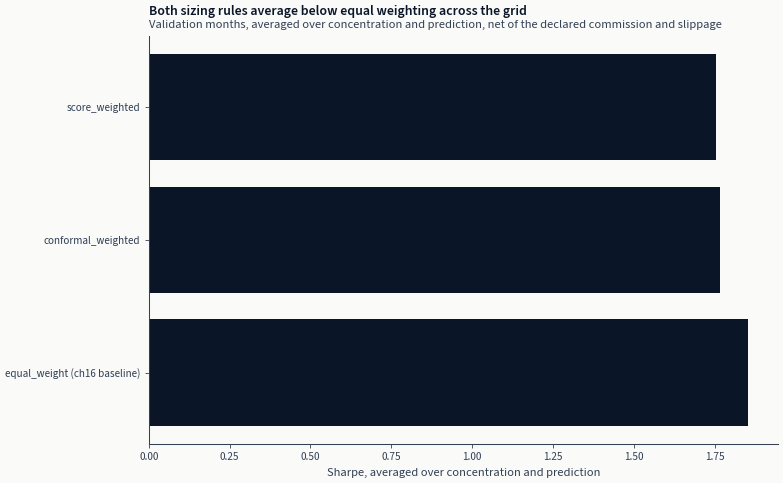

In [12]:
import matplotlib.pyplot as plt

if not allocator_comparison.is_empty():
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(
        allocator_comparison["allocator"].to_list(),
        allocator_comparison["avg_sharpe"].to_list(),
        color=COLORS["blue"],
    )
    ax.set_xlabel("Sharpe, averaged over concentration and prediction")
    add_message_title(
        ax,
        "Both sizing rules average below equal weighting across the grid",
        subtitle=(
            "Validation months, averaged over concentration and prediction, "
            "net of the declared commission and slippage"
        ),
    )
    fig.tight_layout()
    fig.show()

### The upper tail of the allocation grid

The ten highest allocation-stage Sharpes, with the concentration and allocator
behind each. Read it against the table above rather than on its own: this is the
tail of a grid, so the top row is the largest of eighty draws and is inflated by
that count. What is worth reading here is whether one allocator or one
concentration fills the tail, which would be a pattern, or whether the tail is
mixed, which would say the grid found no reliable ordering.

In [13]:
top10 = explorer.best(
    stage="allocation", top_n=10, label=LABEL, prediction_hashes=ADVANCED_HASHES
).join(grid.filter(pl.col("stage") == "allocation").drop("stage"), on="backtest_hash", how="left")
print(top10.select("source", "allocator", "names_per_side", "sharpe", "cagr", "max_drawdown"))

shape: (10, 6)
┌───────────────────┬────────────────────┬────────────────┬──────────┬──────────┬──────────────┐
│ source            ┆ allocator          ┆ names_per_side ┆ sharpe   ┆ cagr     ┆ max_drawdown │
│ ---               ┆ ---                ┆ ---            ┆ ---      ┆ ---      ┆ ---          │
│ str               ┆ str                ┆ i64            ┆ f64      ┆ f64      ┆ f64          │
╞═══════════════════╪════════════════════╪════════════════╪══════════╪══════════╪══════════════╡
│ gbm/leaves_63_mse ┆ conformal_weighted ┆ 50             ┆ 3.04527  ┆ 0.922804 ┆ -0.103744    │
│ gbm/leaves_7_mse  ┆ conformal_weighted ┆ 50             ┆ 2.862337 ┆ 1.171519 ┆ -0.120639    │
│ gbm/default_mse   ┆ conformal_weighted ┆ 50             ┆ 2.587476 ┆ 0.871212 ┆ -0.133559    │
│ gbm/leaves_31_mse ┆ conformal_weighted ┆ 50             ┆ 2.577394 ┆ 0.884798 ┆ -0.168168    │
│ gbm/leaves_15_mse ┆ conformal_weighted ┆ 50             ┆ 2.565322 ┆ 0.973308 ┆ -0.096027    │
│ gbm/leaves_7_

## What this notebook establishes, and what it does not

The sweep answers a narrow question: holding the prediction and the concentration
fixed, does sizing positions by the model's score or by a conformal interval earn
more than sizing them equally? The comparison is clean in the sense that every
allocator saw the same selected names at the same concentration.

It is not clean in a second sense, and that carries forward. The predictions that
entered were the ones that ranked highest at the equal-weight baseline, so this
stage inherits that selection and adds a grid of its own on top. Both counts feed
the trial count the strategy analysis notebook has to deflate by, and neither
number is visible in a Sharpe read off the table above.

Every Sharpe here is already net of the commission and slippage `setup.yaml`
declares, charged on turnover at each rebalance. What has not been tested is
whether that one cost assumption is the right one. That matters more at this stage
than at the last, because the allocators differ in how much they trade: a rule that
re-sizes every position each month turns over more than one that only changes which
names are held, so a cost assumption that is too low flatters the more active rule
specifically. A comparison run at a single cost level cannot show that.

**Next:** the costs notebook re-runs these strategies across a range of cost
assumptions and asks which results hold their ordering as costs rise.